In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [6]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

In [7]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [9]:
nav["date"] = pd.to_datetime(nav["date"])

In [10]:
nav = nav.sort_values(["amfi_code", "date"])

In [11]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [12]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [13]:
returns = nav.dropna(subset=["daily_return"])

In [14]:
returns.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [15]:
risk_report = []

In [16]:
for scheme, group in returns.groupby("amfi_code"):

    r = group["daily_return"]

    # Historical VaR (95%)
    var95 = np.percentile(r, 5)

    # Conditional VaR (Expected Shortfall)
    cvar95 = r[r <= var95].mean()

    risk_report.append({
        "amfi_code": scheme,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

In [17]:
risk_df = pd.DataFrame(risk_report)

In [18]:
risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [19]:
risk_df.shape

(40, 3)

In [20]:
risk_df.to_csv("../reports/var_cvar_report.csv", index=False)

In [21]:
import os

os.path.exists("../reports/var_cvar_report.csv")

True

In [22]:
nav["rolling_sharpe"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(lambda x: (x.rolling(90).mean() / x.rolling(90).std()) * np.sqrt(252))
)

In [23]:
nav.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


In [24]:
top5_funds = nav["amfi_code"].unique()[:5]
top5_funds

array([100016, 100025, 100033, 101206, 101207])

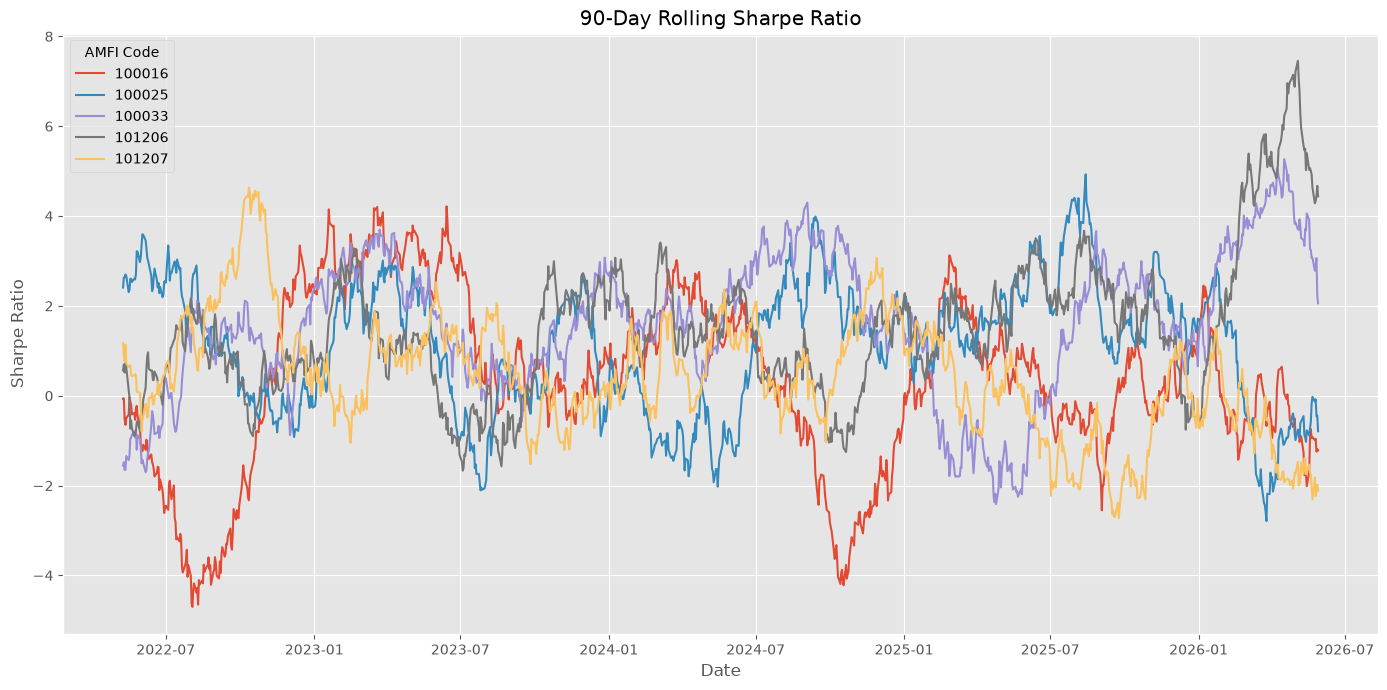

In [25]:
plt.figure(figsize=(14, 7))

for fund in top5_funds:
    data = nav[nav["amfi_code"] == fund]

    plt.plot(
        data["date"],
        data["rolling_sharpe"],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.tight_layout()

In [26]:
plt.savefig("../reports/rolling_sharpe_chart.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

In [27]:
import os

os.path.exists("../reports/rolling_sharpe_chart.png")

True

In [28]:
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [29]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

In [30]:
first_txn = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = first_txn["transaction_date"].dt.year

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [31]:
transactions = transactions.merge(
    first_txn[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

In [32]:
sip_avg = (
    transactions[transactions["transaction_type"] == "SIP"]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .rename("avg_sip_amount")
)

In [33]:
total_invested = (
    transactions.groupby("cohort_year")["amount_inr"]
    .sum()
    .rename("total_invested")
)

In [34]:
top_fund = (
    transactions.groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund.sort_values(["cohort_year", "count"], ascending=[True, False])
    .drop_duplicates("cohort_year")
    [["cohort_year", "amfi_code"]]
)

top_fund = top_fund.rename(columns={"amfi_code": "top_fund"})

In [35]:
cohort_analysis = (
    pd.concat([sip_avg, total_invested], axis=1)
    .reset_index()
)

cohort_analysis = cohort_analysis.merge(
    top_fund,
    on="cohort_year"
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,top_fund
0,2024,10996.885825,3491125187,148568
1,2025,13505.209581,30455243,119599


In [36]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

In [37]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

In [38]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

In [39]:
sip_count = (
    sip.groupby("investor_id")
       .size()
       .rename("sip_count")
)

In [40]:
avg_gap = (
    sip.groupby("investor_id")["gap_days"]
       .mean()
       .rename("avg_gap")
)

In [41]:
sip_analysis = pd.concat(
    [sip_count, avg_gap],
    axis=1
).reset_index()

In [42]:
sip_analysis = sip_analysis[
    sip_analysis["sip_count"] >= 6
]

In [43]:
sip_analysis["status"] = np.where(
    sip_analysis["avg_gap"] > 35,
    "At-Risk",
    "Regular"
)

In [44]:
sip_analysis.head()

,investor_id,sip_count,avg_gap,status
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk


In [45]:
sip_analysis.shape

(1362, 4)

In [46]:
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

In [47]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [48]:
performance["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [49]:
risk = input(
    "Enter Risk Appetite (Low, Moderate, Moderately High, High, Very High): "
)

In [50]:
recommendation = (
    performance[
        performance["risk_grade"].str.lower() == risk.lower()
    ]
    .sort_values("sharpe_ratio", ascending=False)
    .head(3)
)

In [51]:
recommendation = recommendation[
    [
        "amfi_code",
        "scheme_name",
        "risk_grade",
        "sharpe_ratio",
        "fund_house",
        "category"
    ]
]

recommendation

,amfi_code,scheme_name,risk_grade,sharpe_ratio,fund_house,category
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06,HDFC Mutual Fund,Large Cap
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06,Mirae Asset MF,Large Cap
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03,ICICI Prudential MF,Large Cap


In [52]:
performance.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

# Advanced Insights

### 1. Historical Risk Analysis
Historical VaR and CVaR identified the schemes with the largest potential downside risk. Funds with more negative VaR values indicate higher potential daily losses under adverse market conditions.

### 2. Rolling Sharpe Analysis
The 90-day rolling Sharpe Ratio showed that risk-adjusted performance changes over time rather than remaining constant. Some funds maintained more stable Sharpe ratios than others.

### 3. Investor Cohort Analysis
The 2024 cohort contributed the highest total investment, while the 2025 cohort had a higher average SIP amount, indicating stronger average contributions from newer investors.

### 4. SIP Continuity Analysis
Out of all investors with six or more SIP transactions, several were flagged as "At-Risk" because their average gap between SIPs exceeded 35 days. These investors may require engagement to improve continuity.

### 5. Fund Recommendation
The recommendation engine successfully suggests the top three funds for each risk category using the Sharpe Ratio, helping investors identify strong risk-adjusted performers.